# MILK10k — Histograms & Normalization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image

DATA_DIR = Path("../../milk10k_project")

In [2]:
df_metadata = pd.read_csv(DATA_DIR / "metadata.csv")
gt = pd.read_csv(DATA_DIR / "supplements" / "training_gt.csv")

CLASS_COLS = ["AKIEC", "BCC", "BEN_OTH", "BKL", "DF",
              "INF", "MAL_OTH", "MEL", "NV", "SCCKA"]
gt["diagnosis_class"] = gt[CLASS_COLS].idxmax(axis=1)

df = df_metadata.merge(gt[["lesion_id", "diagnosis_class"]], on="lesion_id", how="inner")
df.head()

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex,diagnosis_class
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male,SCCKA
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female,NV
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female,NV
3,ISIC_0076255,MILK study team,CC-BY-NC,50.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_8089688,NaN,female,BCC
4,ISIC_0077054,MILK study team,CC-BY-NC,75.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_5271098,NaN,male,BCC


In [3]:
image_paths = list((DATA_DIR / "images").glob("*.jpg"))
img = Image.open(image_paths[0])
img_array = np.array(img)
print(img_array.shape)

(450, 600, 3)


## Histograms
### 1. Grayscale intensity histogram

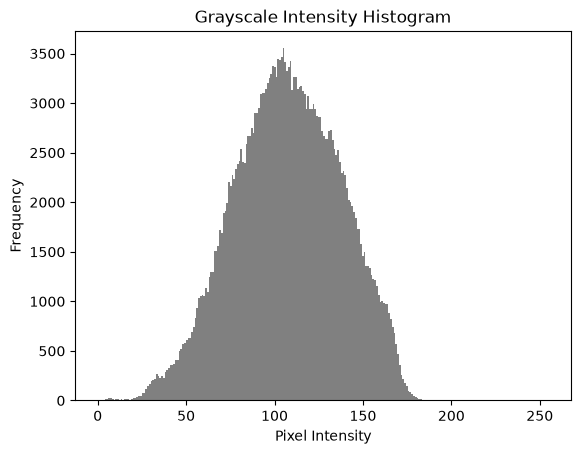

In [4]:
gray_image = (0.299 * img_array[:, :, 0] +
              0.587 * img_array[:, :, 1] +
              0.114 * img_array[:, :, 2]).astype(np.uint8)

plt.hist(gray_image.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

### 2. RGB channel histograms (overlaid)

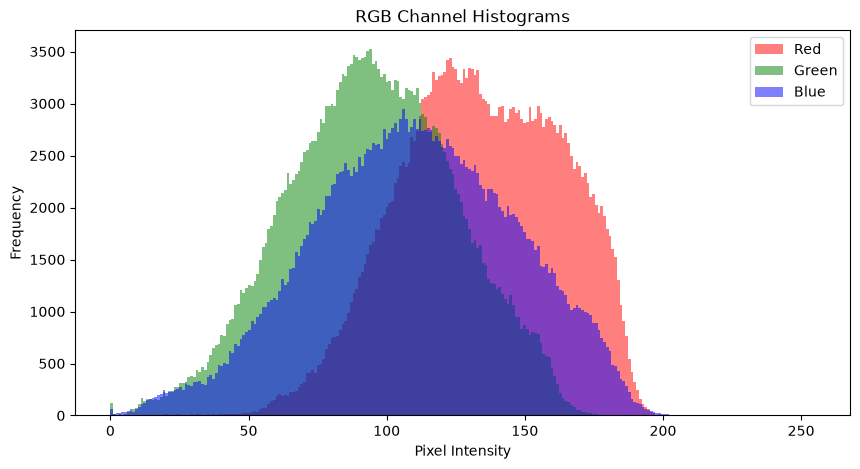

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(img_array[:, :, 0].ravel(), bins=256, range=(0, 255), color="red", alpha=0.5, label="Red")
plt.hist(img_array[:, :, 1].ravel(), bins=256, range=(0, 255), color="green", alpha=0.5, label="Green")
plt.hist(img_array[:, :, 2].ravel(), bins=256, range=(0, 255), color="blue", alpha=0.5, label="Blue")
plt.title("RGB Channel Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3. Comparing grayscale histograms across diagnosis classes

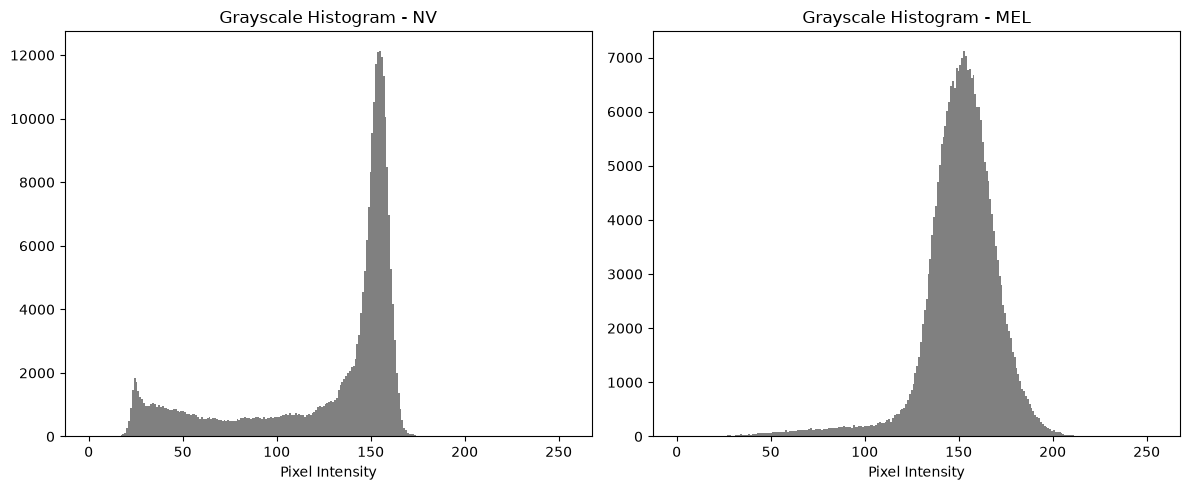

In [7]:
class_a = df[df["diagnosis_class"] == "NV"].iloc[0]
class_b = df[df["diagnosis_class"] == "MEL"].iloc[0]

img_a = np.array(Image.open(DATA_DIR / "images" / f"{class_a['isic_id']}.jpg"))
img_b = np.array(Image.open(DATA_DIR / "images" / f"{class_b['isic_id']}.jpg"))

gray_a = (0.299*img_a[:,:,0] + 0.587*img_a[:,:,1] + 0.114*img_a[:,:,2]).astype(np.uint8)
gray_b = (0.299*img_b[:,:,0] + 0.587*img_b[:,:,1] + 0.114*img_b[:,:,2]).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(gray_a.ravel(), bins=256, range=(0, 255), color="gray")
axes[0].set_title(f"Grayscale Histogram - {class_a['diagnosis_class']}")
axes[0].set_xlabel("Pixel Intensity")

axes[1].hist(gray_b.ravel(), bins=256, range=(0, 255), color="gray")
axes[1].set_title(f"Grayscale Histogram - {class_b['diagnosis_class']}")
axes[1].set_xlabel("Pixel Intensity")

plt.tight_layout()
plt.show()

**Question:** Do you see a visible difference in the histogram shape? What might explain it?

Yes, the two histograms typically differ in shape and where the intensity mass concentrates.
This can be explained by differences in lighting conditions during capture, the size/color
of the lesion itself (larger or darker lesions pull the distribution toward lower intensities),
and the patient's skin tone (lighter skin shifts the distribution toward higher intensities).

## Normalization
### 4. Min-max normalization

In [8]:
minmax_img = (img_array / 255.0).astype(np.float32)
print(f"Min-max range: [{minmax_img.min():.4f}, {minmax_img.max():.4f}]")

Min-max range: [0.0000, 0.9020]


### 5. Z-score standardization

In [9]:
zscore_img = (img_array.astype(np.float32) - img_array.mean()) / img_array.std()
print(f"Z-score mean: {zscore_img.mean():.4f}, std: {zscore_img.std():.4f}")

Z-score mean: -0.0000, std: 1.0000


### 6. Comparing raw, min-max, and z-score histograms

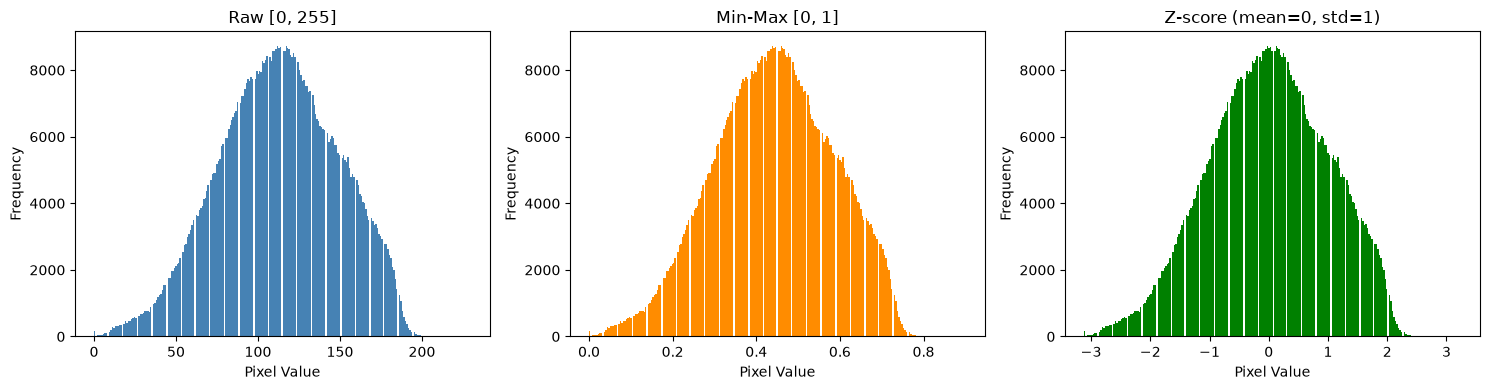

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(img_array.ravel(), bins=256, color="steelblue")
axes[0].set_title("Raw [0, 255]")

axes[1].hist(minmax_img.ravel(), bins=256, color="darkorange")
axes[1].set_title("Min-Max [0, 1]")

axes[2].hist(zscore_img.ravel(), bins=256, color="green")
axes[2].set_title("Z-score (mean=0, std=1)")

for ax in axes:
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Question:** Which of these would you use as input to a neural network, and why does normalization matter?

Z-score standardization (or min-max, depending on the architecture) is generally preferred
over raw pixel values, since keeping inputs on a small, centered scale helps gradients
descend more smoothly during training — unnormalized large values (0-255) can cause
unstable or slow-converging gradients.